In [1]:
!pip install -q kaggle

In [1]:
import os
import json

os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_credentials = {
    "username": "shreeramkumarsingh",
    "key": "dad2570e37516844ec156a8c4d550978"
}

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)

os.chmod("/root/.kaggle/kaggle.json", 600)

In [2]:
!mkdir -p /content/data

!kaggle datasets download \
    -d salader/dogsvscats \
    -p /content/data \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:08<00:00, 136MB/s] 



In [5]:
!find /content/data -maxdepth 3 -type d

/content/data
/content/data/catsvsdogs
/content/data/catsvsdogs/train
/content/data/catsvsdogs/train/cats
/content/data/catsvsdogs/train/dogs
/content/data/catsvsdogs/test
/content/data/catsvsdogs/test/cats
/content/data/catsvsdogs/test/dogs
/content/data/train
/content/data/train/cats
/content/data/train/dogs
/content/data/test
/content/data/test/cats
/content/data/test/dogs


In [6]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [7]:
# generators
#https://keras.io/api/data_loading/image/

train_ds = keras.utils.image_dataset_from_directory(
    directory= '/content/data/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory= '/content/data/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [8]:
# Normalize
def process(image,label):
    image = tf.cast(image/255,tf.float32)
    return image,label
trian_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [11]:
# create CNN model
# ==========================================
# 4. CNN MODEL ARCHITECTURE
# ==========================================

model = Sequential()

# 1st Convolutional Block
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

# 2nd Convolutional Block
model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

# 3rd Convolutional Block
model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

# Flattening and Fully Connected Layers
model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))


# Output Layer for Binary Classification
model.add(Dense(1,activation='sigmoid'))


In [12]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
# ==========================================
# 5. MODEL COMPILATION & TRAINING
# ==========================================
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [15]:
# Execute training across 10 epochs
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 92ms/step - accuracy: 0.5641 - loss: 1.2650 - val_accuracy: 0.5000 - val_loss: 8.4112
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 94ms/step - accuracy: 0.6214 - loss: 0.6446 - val_accuracy: 0.4722 - val_loss: 0.6941
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 95ms/step - accuracy: 0.6936 - loss: 0.5788 - val_accuracy: 0.5000 - val_loss: 3.4123
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.7369 - loss: 0.5095 - val_accuracy: 0.5000 - val_loss: 0.7089
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.7709 - loss: 0.4476 - val_accuracy: 0.5000 - val_loss: 4.9560
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.8002 - loss: 0.3911 - val_accuracy: 0.5000 - val_loss: 1.0142
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.8177 - loss: 0.3505 - val_accuracy: 0.5000 - val_loss: 1.7307
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.8409 - loss: 0.3085 - 

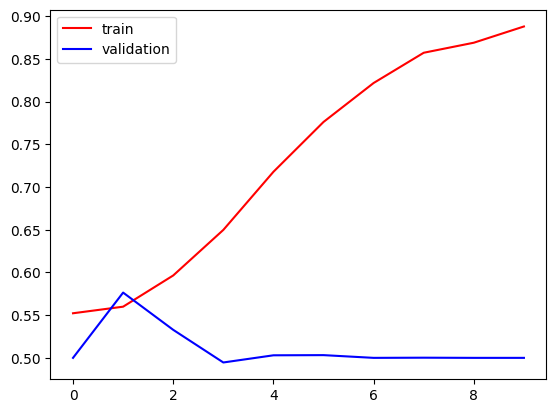

In [ ]:
# ==========================================
# 6. EVALUATION (LOSS & ACCURACY PLOTS)
# ==========================================
# Plot Accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red', label='train')
plt.plot(history.history['val_accuracy'],color='blue', label='validation')
plt.legend()
plt.show()

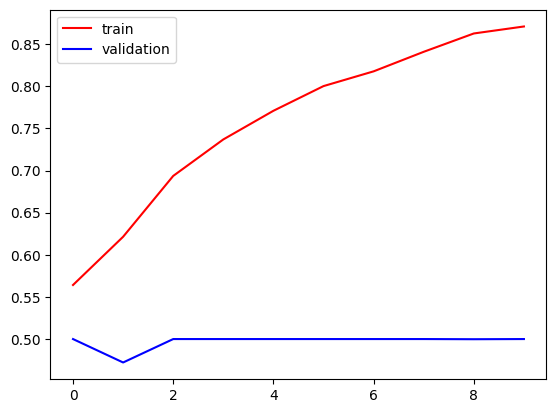

In [16]:
# after normalization and dropout 
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red', label='train')
plt.plot(history.history['val_accuracy'],color='blue', label='validation')
plt.legend()
plt.show()

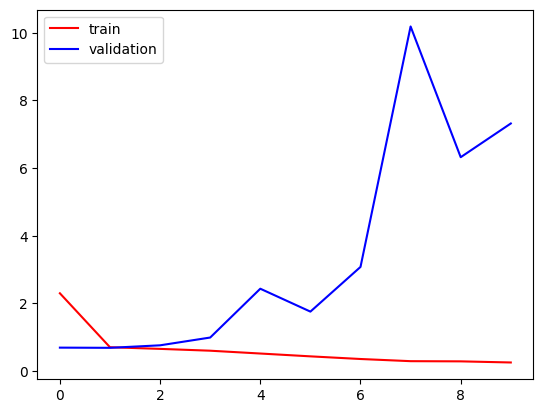

In [ ]:
# Plot Loss
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

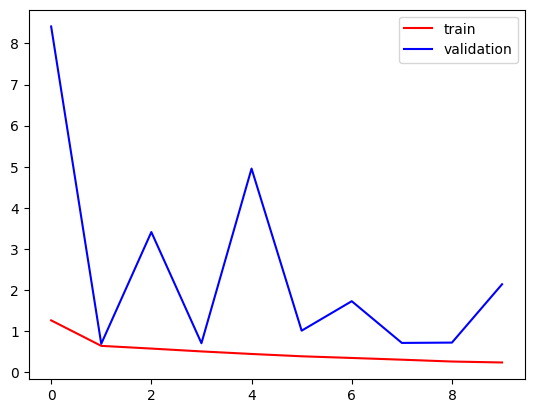

In [17]:
# after normalization and dropout
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
# ways to reduce overfittting

# Add more data
# Data Augmentaion -> next video
# L1/L2 Regularization
# Dropout
# Batch Norm
# Reduce complexity


Testing image: /content/data/catsvsdogs/test/cats/cat.5580.jpg


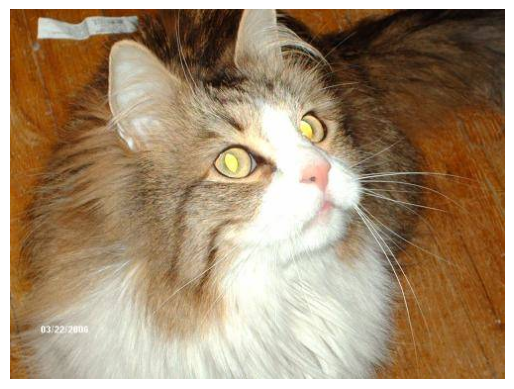

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Raw Prediction Value: 0.01420650165528059
Prediction: It's a CAT!


In [31]:
# ==========================================
# 7. INFERENCE (PREDICTING ON NEW IMAGES)
# ==========================================

import os
import cv2
import matplotlib.pyplot as plt

# Folder containing cat images
folder_path = '/content/data/catsvsdogs/test/cats'

# Select the first image
image_name = os.listdir(folder_path)[0]
image_path = os.path.join(folder_path, image_name)

print("Testing image:", image_path)

if os.path.exists(image_path):

    # Read image
    test_img = cv2.imread(image_path)

    # Convert BGR → RGB for displaying
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

    # Display image
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Resize to model input size
    test_img_resized = cv2.resize(test_img, (256, 256))

    # Add batch dimension
    test_input = test_img_resized.reshape((1, 256, 256, 3))

    # Scale pixels
    test_input = test_input / 255.0

    # Prediction
    prediction = model.predict(test_input)

    print(f"Raw Prediction Value: {prediction[0][0]}")

    if prediction[0][0] < 0.5:
        print("Prediction: It's a CAT!")
    else:
        print("Prediction: It's a DOG!")

else:
    print(f"Image not found at {image_path}")